In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("sample_data/insurance.csv")

In [11]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [12]:
df.shape

(1338, 7)

In [13]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [15]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# **EDA DATA VISULAIZATION **

In [17]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [18]:
numeric_columns = ['age','bmi','children','charges']

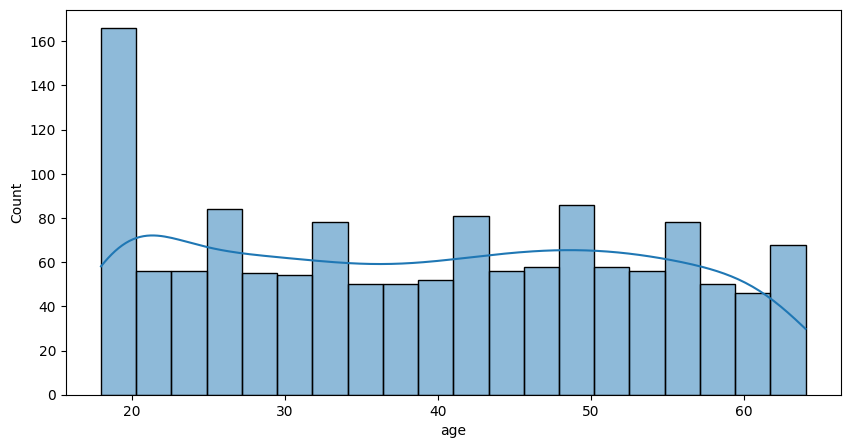

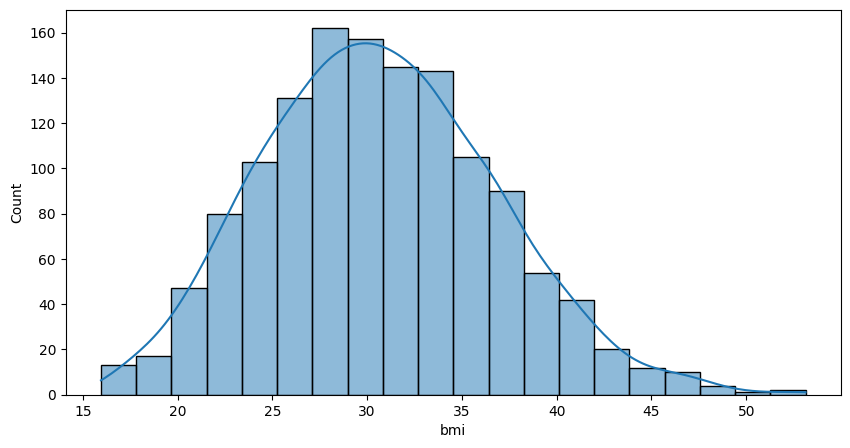

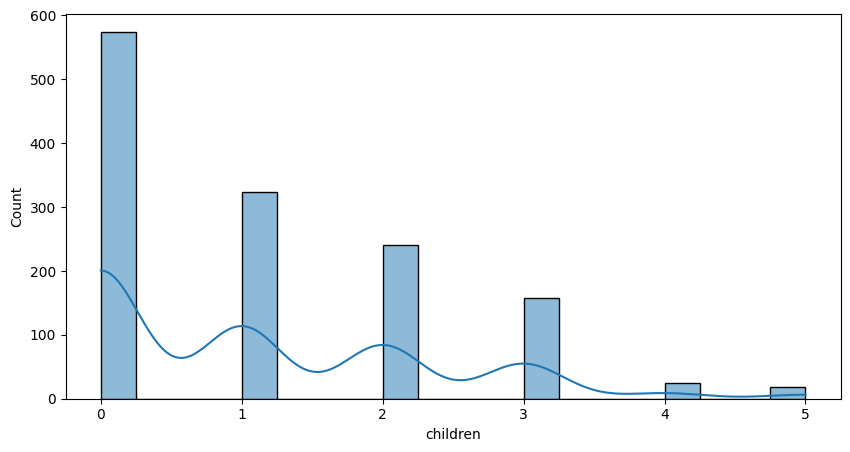

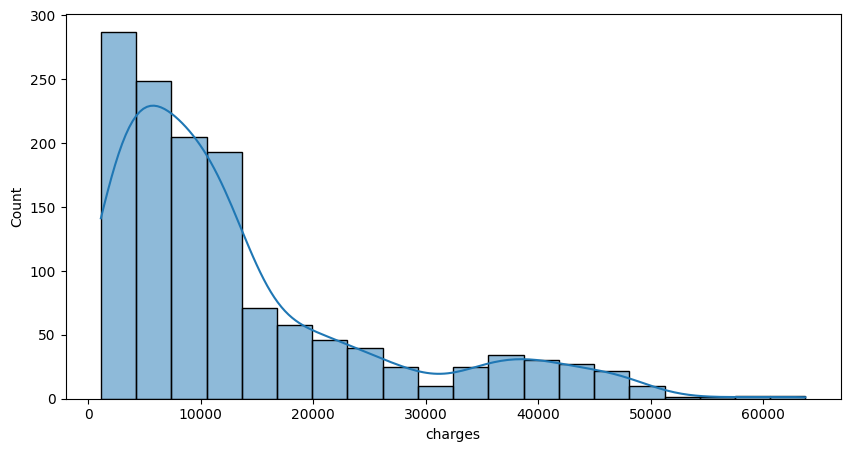

In [19]:
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col],kde=True,bins=20)
  plt.xlabel(col)
  plt.show()

<Axes: xlabel='children', ylabel='count'>

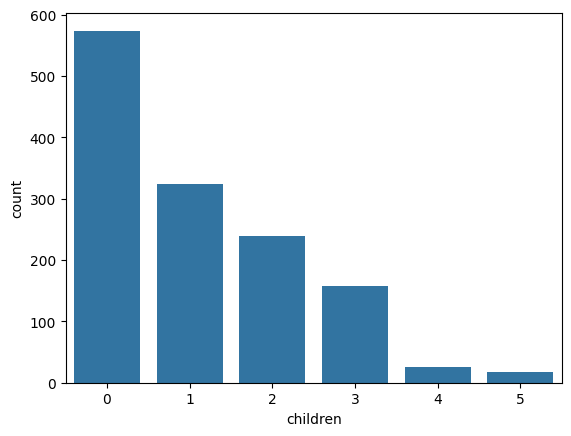

In [20]:
sns.countplot(x=df["children"])

<Axes: xlabel='sex', ylabel='count'>

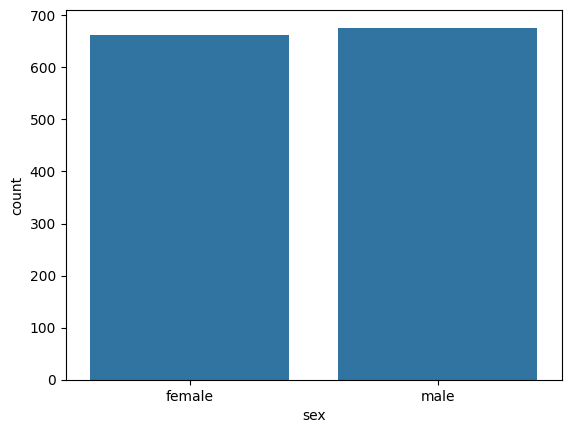

In [21]:
sns.countplot(x=df["sex"])

<Axes: xlabel='smoker', ylabel='count'>

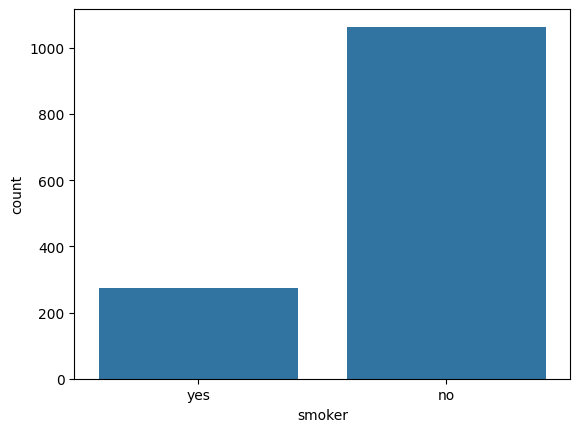

In [22]:
sns.countplot(x=df["smoker"])

**Detect Outliers in data set**

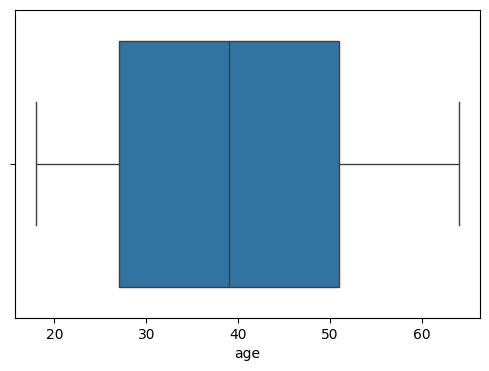

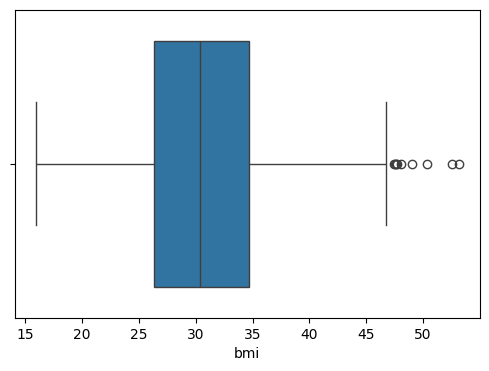

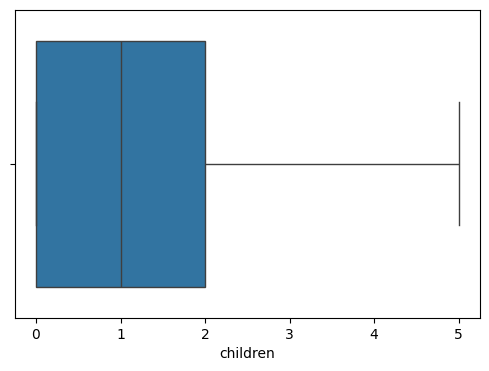

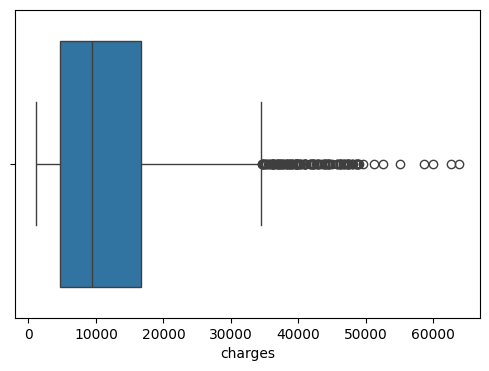

In [25]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.xlabel(col)
  plt.show()

**Check Co-relation in DAta **

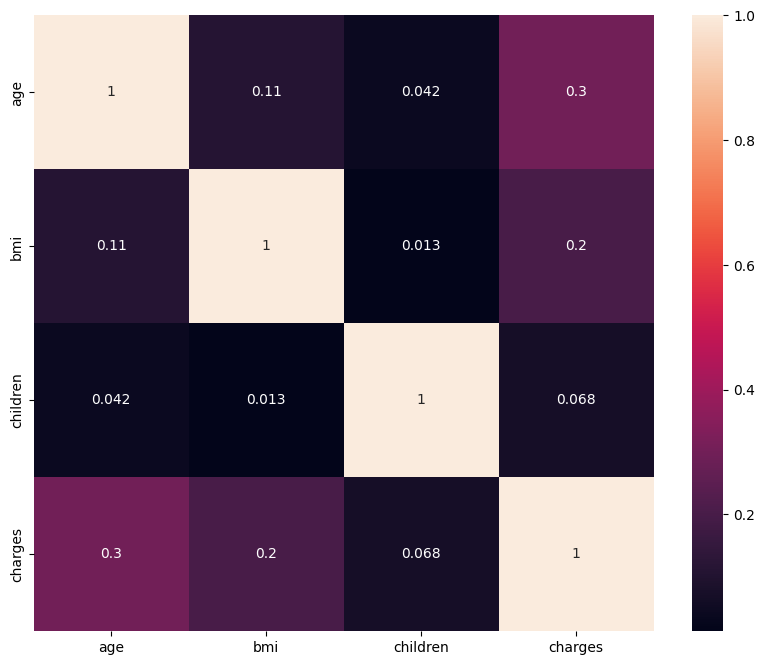

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Data Cleaning & Preprocessing

In [28]:
data_cleaned = df.copy()

In [31]:
data_cleaned.shape

(1338, 7)

In [32]:
data_cleaned.drop_duplicates(inplace=True)

In [33]:
data_cleaned.shape

(1337, 7)

In [35]:
data_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [36]:
data_cleaned["sex"].value_counts()

,count
sex,
male,675
female,662


**Encode sex column from object to int type**

In [38]:
data_cleaned ["sex"] = data_cleaned["sex"].map({"male":0 , "female":1})


In [43]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


**Encode Smoker column from obj to **

In [40]:
data_cleaned["smoker"].value_counts()

,count
smoker,
no,1063
yes,274


In [41]:
data_cleaned ["smoker"] = data_cleaned["smoker"].map({"no":0 , "yes":1})


In [42]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


**Rename Column Sex **

In [44]:
data_cleaned.rename(columns={"sex":"gender"},inplace=True)

In [45]:
data_cleaned.head()

,age,gender,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


**One Hot Encoding region column into int **

In [47]:
data_cleaned["region"].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [48]:
data_cleaned = pd.get_dummies(data_cleaned , columns= ["region"])

In [49]:
data_cleaned.head()

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [59]:
data_cleaned.astype(int)

ValueError: Cannot cast object dtype to int64

# Feature Engineering And Extraction

<Axes: xlabel='bmi', ylabel='Count'>

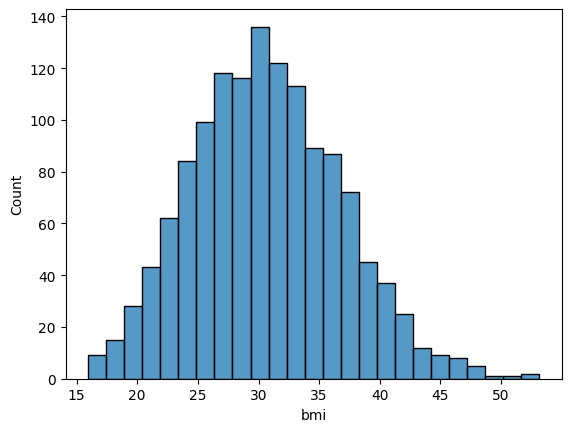

In [52]:
sns.histplot(df["bmi"])

In [56]:
data_cleaned["bmi_catagory"] = pd.cut(
    data_cleaned['bmi'] ,
    bins = [0,18.5,24.9,29.9,float("inf")],
    labels=["Underweight","Normal","Overweight","Obese"]
)

In [62]:
data_cleaned.head()

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_catagory
0,19,1,27.900,0,1,16884.92400,False,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,False,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,False,True,False,False,Overweight


In [63]:
data_cleaned = pd.get_dummies(data_cleaned , columns= ["bmi_catagory"])

In [64]:
data_cleaned.astype(int)

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_catagory_Underweight,bmi_catagory_Normal,bmi_catagory_Overweight,bmi_catagory_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


# Feature Scaling

In [65]:
data_cleaned.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_catagory_Underweight', 'bmi_catagory_Normal',
       'bmi_catagory_Overweight', 'bmi_catagory_Obese'],
      dtype='object')

In [67]:
from sklearn.preprocessing import StandardScaler

In [70]:
cols = ["age","bmi","children",]
scalar = StandardScaler()

data_cleaned[cols] = scalar.fit_transform(data_cleaned[cols])

In [71]:
data_cleaned.head()

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_catagory_Underweight,bmi_catagory_Normal,bmi_catagory_Overweight,bmi_catagory_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,False,False,False,True,False,False,True,False
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,False,False,True,False,False,False,False,True
2,-0.799350,0,0.383155,1.580143,0,4449.46200,False,False,True,False,False,False,False,True
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,False,True,False,False,False,True,False,False
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,False,True,False,False,False,False,True,False


In [74]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features =  [
  'age', 'gender', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_catagory_Underweight', 'bmi_catagory_Normal',
       'bmi_catagory_Overweight', 'bmi_catagory_Obese']


correlations = {
    feature: pearsonr(data_cleaned[feature], data_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
5,charges,1.000000
4,smoker,0.787234
0,age,0.298308
2,bmi,0.198401
13,bmi_catagory_Obese,0.197659
8,region_southeast,0.073578
3,children,0.067389
6,region_northeast,0.005945
7,region_northwest,-0.038695
9,region_southwest,-0.043637


In [75]:
cat_features = [ 'gender', 'children', 'smoker',
        'region_northwest', 'region_southeast',
       'region_southwest',  'bmi_catagory_Normal',
       'bmi_catagory_Overweight', 'bmi_catagory_Obese']

In [76]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

data_cleaned['charges_bin'] = pd.qcut(data_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(data_cleaned[col], data_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
smoker,848.219178,0.0,Reject Null (Keep Feature)
children,138.659313,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
gender,10.258784,0.01649,Reject Null (Keep Feature)
bmi_catagory_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_catagory_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_catagory_Overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [79]:
final_df = data_cleaned[['age', 'gender', 'bmi', 'children', 'smoker', 'charges','region_southeast']]


In [80]:
final_df


,age,gender,bmi,children,smoker,charges,region_southeast
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,False
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,True
2,-0.799350,0,0.383155,1.580143,0,4449.46200,True
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,False
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,False
...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,False
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,False
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,True
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,False
